In [1]:
!pip -q install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
!aws s3 ls s3://openfold/ --no-sign-request

                           PRE ablation_checkpoints/
                           PRE alignment_databases/
                           PRE alignment_db/
                           PRE benchmarking_data/
                           PRE converted_checkpoints/
                           PRE data_caches/
                           PRE openfold3_params/
                           PRE openfold_params/
                           PRE openfold_soloseq_params/
                           PRE pdb/
                           PRE soloseq_embeddings/
                           PRE staging/
                           PRE uniclust30/
                           PRE uniclust30_unfiltered/
2022-06-17 03:35:44      18657 LICENSE
2022-08-28 21:57:09    4524064 duplicate_pdb_chains.txt
2024-01-30 15:58:40 55588453165 pdb_mmcif.zip


## Bajar 50 protenias

In [3]:
!mkdir -p /content/af_subset/msas
!mkdir -p /content/af_subset/jsons
!mkdir -p /content/af_subset/meta

In [4]:
!aws s3 cp s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json \
  /content/af_subset/jsons/ --no-sign-request

download: s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json to af_subset/jsons/fb_protein.json


In [5]:
import json
from pathlib import Path

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

targets = []
for qname, q in data["queries"].items():
    for chain in q["chains"]:
        for cid in chain["chain_ids"]:
            if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
                targets.append(f"{qname.lower()}_{cid}")
                break
        break

targets = sorted(set(targets))
print("n targets:", len(targets))
print(targets[:20])

with open("/content/af_subset/fb_targets_50.txt", "w") as f:
    for t in targets[:50]:
        f.write(t + "\n")

n targets: 239
['7qrj_A', '7qrr_A', '7quv_A', '7qwe_A', '7spq_A', '7th0_A', '7txy_A', '7uq2_A', '7vub_A', '7wr3_A', '7x36_A', '7x80_A', '7xfr_A', '7xft_A', '7xl7_A', '7xn2_A', '7xpi_A', '7xpt_A', '7xrb_A', '7xvq_A']


In [6]:
%%bash
mkdir -p /content/af_subset/foldbench_msas

while read t; do
  echo "Downloading $t"
  aws s3 cp "s3://openfold/benchmarking_data/msas/foldbench_msas/$t/" \
            "/content/af_subset/foldbench_msas/$t/" \
            --recursive --no-sign-request
done < /content/af_subset/fb_targets_50.txt

download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/VALID_DIR to af_subset/foldbench_msas/7qrj_A/VALID_DIR
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/uniprot_hits.sto to af_subset/foldbench_msas/7qrj_A/uniprot_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/mgnify_hits.sto to af_subset/foldbench_msas/7qrj_A/mgnify_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/uniref90_hits.sto to af_subset/foldbench_msas/7qrj_A/uniref90_hits.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/hmm_output.sto to af_subset/foldbench_msas/7qrj_A/hmm_output.sto
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrj_A/cfdb_hits.a3m to af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrr_A/VALID_DIR to af_subset/foldbench_msas/7qrr_A/VALID_DIR
download: s3://openfold/benchmarking_data/msas/foldbench_msas/7qrr_A/mgn

In [7]:
!aws s3 ls s3://openfold/benchmarking_data/reference_structures/ --recursive --no-sign-request | grep -Ei '7QRJ|7QRR|7QUV|7SPQ|7WR3' | head -n 50

2025-11-26 05:15:10     793225 benchmarking_data/reference_structures/foldbench_protein/7qrj-assembly1_68.cif
2025-11-26 05:15:10     272054 benchmarking_data/reference_structures/foldbench_protein/7qrr-assembly1_67.cif
2025-11-26 05:15:11     164863 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_70.cif
2025-11-26 05:15:11     146719 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_71.cif
2025-11-26 05:15:11    1138414 benchmarking_data/reference_structures/foldbench_protein/7spq-assembly1_142.cif
2025-11-26 05:15:11     864856 benchmarking_data/reference_structures/foldbench_protein/7wr3-assembly1_167.cif


In [8]:
%%bash
mkdir -p /content/af_subset/reference_structures

while read t; do
  pdb=$(echo "$t" | cut -d'_' -f1 | tr '[:upper:]' '[:lower:]')
  echo "Searching structure for $pdb"

  file=$(aws s3 ls s3://openfold/benchmarking_data/reference_structures/foldbench_protein/ --no-sign-request \
    | awk '{print $4}' \
    | grep -E "^${pdb}-assembly1_.*\.cif$" \
    | head -n 1)

  if [ -n "$file" ]; then
    echo "Downloading $file"
    aws s3 cp "s3://openfold/benchmarking_data/reference_structures/foldbench_protein/$file" \
              "/content/af_subset/reference_structures/$file" \
              --no-sign-request
  else
    echo "NO STRUCTURE FOUND FOR $pdb"
  fi
done < /content/af_subset/fb_targets_50.txt

Searching structure for 7qrj
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qrj-assembly1_68.cif to af_subset/reference_structures/7qrj-assembly1_68.cif
Searching structure for 7qrr
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qrr-assembly1_67.cif to af_subset/reference_structures/7qrr-assembly1_67.cif
Searching structure for 7quv
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_70.cif to af_subset/reference_structures/7quv-assembly1_70.cif
Searching structure for 7qwe
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7qwe-assembly1_206.cif to af_subset/reference_structures/7qwe-assembly1_206.cif
Searching structure for 7spq
download: s3://openfold/benchmarking_data/reference_structures/foldbench_protein/7spq-assembly1_142.cif to af_subset/reference_structures/7spq-assembly1_142.cif
Searching structure for 7th0
download: s3://openfold/ben

In [9]:
!ls /content/af_subset/reference_structures | head
!ls /content/af_subset/reference_structures | wc -l

7qrj-assembly1_68.cif
7qrr-assembly1_67.cif
7quv-assembly1_70.cif
7qwe-assembly1_206.cif
7spq-assembly1_142.cif
7th0-assembly1_130.cif
7txy-assembly1_58.cif
7uq2-assembly1_113.cif
7vub-assembly1_178.cif
7wr3-assembly1_167.cif
50


## Crear un dataset de Referencia

In [10]:
import json
from pathlib import Path
import pandas as pd

json_path = Path("/content/af_subset/jsons/fb_protein.json")
msa_root = Path("/content/af_subset/foldbench_msas")
cif_root = Path("/content/af_subset/reference_structures")

with open(json_path, "r") as f:
    data = json.load(f)

rows = []

for qname, q in data["queries"].items():
    chain = q["chains"][0]
    chain_ids = chain["chain_ids"]
    sequence = chain["sequence"]

    # elegimos la primera cadena alfabética simple, como hicimos al descargar MSAs
    chosen_chain = None
    for cid in chain_ids:
        if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
            chosen_chain = cid
            break

    if chosen_chain is None:
        continue

    msa_dir_name = f"{qname.lower()}_{chosen_chain}"
    msa_dir = msa_root / msa_dir_name

    cif_candidates = list(cif_root.glob(f"{qname.lower()}-assembly1_*.cif"))
    cif_file = cif_candidates[0] if len(cif_candidates) > 0 else None

    rows.append({
        "query_name": qname,
        "chain_id": chosen_chain,
        "msa_dir_name": msa_dir_name,
        "msa_exists": msa_dir.exists(),
        "msa_dir": str(msa_dir),
        "cif_exists": cif_file is not None,
        "cif_file": str(cif_file) if cif_file is not None else None,
        "seq_len": len(sequence),
        "sequence": sequence})

df_map = pd.DataFrame(rows)
df_map = df_map.dropna(subset=['cif_file'])
print("\nN total:", len(df_map))
print("MSA disponibles:", df_map["msa_exists"].sum())
print("CIF disponibles:", df_map["cif_exists"].sum())
print("Ambos disponibles:", (df_map["msa_exists"] & df_map["cif_exists"]).sum())


N total: 50
MSA disponibles: 50
CIF disponibles: 50
Ambos disponibles: 50


In [11]:
df_map

,query_name,chain_id,msa_dir_name,msa_exists,msa_dir,cif_exists,cif_file,seq_len,sequence
0,7QRJ,A,7qrj_A,True,/content/af_subset/foldbench_msas/7qrj_A,True,/content/af_subset/reference_structures/7qrj-a...,184,MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHL...
1,7QRR,A,7qrr_A,True,/content/af_subset/foldbench_msas/7qrr_A,True,/content/af_subset/reference_structures/7qrr-a...,153,MSVYGPVPTVTTRAFLPRLATAADSITSTTTTIALDPQTEQSYWTR...
2,7QUV,A,7quv_A,True,/content/af_subset/foldbench_msas/7quv_A,True,/content/af_subset/reference_structures/7quv-a...,122,GPMTSKMSQLERNIETIINTFHQYSVKLGHPDTLNQGEFKELVRKD...
3,7QWE,A,7qwe_A,True,/content/af_subset/foldbench_msas/7qwe_A,True,/content/af_subset/reference_structures/7qwe-a...,32,XGEIAQALKEIAKALKEIAYALKEIAQALKGX
4,7SPQ,A,7spq_A,True,/content/af_subset/foldbench_msas/7spq_A,True,/content/af_subset/reference_structures/7spq-a...,328,GHMTIKLADNPNRLTDREAMGLPETFVARTPVALLAGHEDLLGAGA...
5,7TH0,A,7th0_A,True,/content/af_subset/foldbench_msas/7th0_A,True,/content/af_subset/reference_structures/7th0-a...,49,MTIAERLRQEGEQSKALHIAKIMLESGVPLADIMRFTGLSEEELAAASQ
6,7TXY,A,7txy_A,True,/content/af_subset/foldbench_msas/7txy_A,True,/content/af_subset/reference_structures/7txy-a...,279,MADRTGIVAGALLPGMPHLLAEHPAPSWSALAGAARDVGARLRRLE...
7,7UQ2,A,7uq2_A,True,/content/af_subset/foldbench_msas/7uq2_A,True,/content/af_subset/reference_structures/7uq2-a...,89,SMIEDIKGYKPHTEEKIGKVNAIKDAEVRLGLIFDALYDEFWEALD...
8,7VUB,A,7vub_A,True,/content/af_subset/foldbench_msas/7vub_A,True,/content/af_subset/reference_structures/7vub-a...,154,MAGQSTHYLAFPRASTITWGDDTRYWSWATVDFCSYAIEEARLLQV...
9,7WR3,A,7wr3_A,True,/content/af_subset/foldbench_msas/7wr3_A,True,/content/af_subset/reference_structures/7wr3-a...,806,GPMKIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKL...


---

# *Visualizar y entender el DataSet*

### Ver una protenia

In [ ]:

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

q = data["queries"]["7QRJ"]

print("query_name:", q["query_name"])
print("chain_ids:", q["chains"][0]["chain_ids"])
print("sequence:")
print(q["chains"][0]["sequence"])
print("length:", len(q["chains"][0]["sequence"]))

query_name: 7QRJ
chain_ids: ['A', 'B', 'E']
sequence:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
length: 184


### Ver un MSA

In [ ]:
msa_path = "/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m"

with open(msa_path, "r") as f:
    lines = f.readlines()

print("Primeras 20 líneas:\n")
for line in lines[:20]:
    print(line.rstrip())

Primeras 20 líneas:

>7qrj_1
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
>tr|I0CER9|I0CER9_9VIRU
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNLRPVNNPEIDFEIFVLDNGTRTTNPGLITLLSNGQILIYKDNNLGQFTVGSGGSGFNPFSITYMI
>SAMN10351357:k141_938366_10
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGLRPTT--EMHFVVHVNDNATGAH--GVFKVNDLGQMVFYASDVQGNFA-GAGSSGVFQTTVSYI-
>SAMN08777771:k141_2134148_2
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDLWPTN--SEEVVLYVEDNLIKKV--GKATIGIAGSINVYADAATGSFA-GSGLSGIQKCTLQYN-
>SAMN10864233:k141_1082461_5
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL

In [ ]:

msa_path = Path("/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m")

seqs = []
names = []

with open(msa_path, "r") as f:
    current_name = None
    current_seq = []
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_name is not None:
                names.append(current_name)
                seqs.append("".join(current_seq))
            current_name = line[1:]
            current_seq = []
        else:
            current_seq.append(line)
    if current_name is not None:
        names.append(current_name)
        seqs.append("".join(current_seq))

print("Número de secuencias en este archivo:", len(seqs))
print("Longitud de la primera secuencia:", len(seqs[0]))
print("\nPrimeros 5 nombres:")
for n in names[:5]:
    print(n)

print("\nPrimeras 5 secuencias recortadas:")
for s in seqs[:5]:
    print(s[:120])

Número de secuencias en este archivo: 1221
Longitud de la primera secuencia: 184

Primeros 5 nombres:
7qrj_1
tr|I0CER9|I0CER9_9VIRU
SAMN10351357:k141_938366_10
SAMN08777771:k141_2134148_2
SAMN10864233:k141_1082461_5

Primeras 5 secuencias recortadas:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADL
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNL
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGL
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDL
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL


### Visualizar conservacion por posicion


In [ ]:
from collections import Counter
import pandas as pd

max_show = 60
msa = seqs[:100]
L = min(len(s) for s in msa)

rows = []
for j in range(min(L, max_show)):
    col = [s[j] for s in msa]
    counts = Counter(col)
    top_char, top_freq = counts.most_common(1)[0]
    rows.append({
        "pos": j + 1,
        "top_aa": top_char,
        "freq": top_freq / len(col),
        "n_unique": len(counts)
    })

df_cons = pd.DataFrame(rows)
print(df_cons.head(10))

   pos top_aa  freq  n_unique
0    1      -  0.98         2
1    2      -  0.98         2
2    3      -  0.98         3
3    4      -  0.98         2
4    5      -  0.98         3
5    6      -  0.98         2
6    7      -  0.98         3
7    8      -  0.98         3
8    9      -  0.98         3
9   10      -  0.98         2


## Visualizar la estructura 3d

In [ ]:
!pip -q install py3Dmol biopython

In [ ]:
import py3Dmol

cif_path = "/content/af_subset/reference_structures/7qrj-assembly1_68.cif"

with open(cif_path, "r") as f:
    cif_str = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(cif_str, "mmcif")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
from Bio.PDB.MMCIFParser import MMCIFParser

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("7qrj", "/content/af_subset/reference_structures/7qrj-assembly1_68.cif")

for model in structure:
    print("Model:", model.id)
    for chain in model:
        print("Chain:", chain.id)
        residues = list(chain.get_residues())
        print("N residuos:", len(residues))
        break
    break

Model: 0
Chain: A
N residuos: 181


In [ ]:
import numpy as np

coords = []
res_ids = []

for model in structure:
    for chain in model:
        if chain.id == "A":
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].coord)
                    res_ids.append(residue.id)
            break
    break

coords = np.array(coords)

print("Shape coords:", coords.shape)
print("Primeras 5 coordenadas:")
print(coords[:10])

Shape coords: (181, 3)
Primeras 5 coordenadas:
[[-10.743  12.501 -37.318]
 [-10.583  16.234 -37.986]
 [-12.536  16.824 -34.756]
 [-10.049  14.71  -32.771]
 [ -7.182  17.197 -33.265]
 [ -6.963  20.989 -33.273]
 [ -9.107  22.604 -35.96 ]
 [-10.629  25.987 -36.771]
 [-14.215  24.706 -36.441]
 [-16.838  26.782 -34.657]]


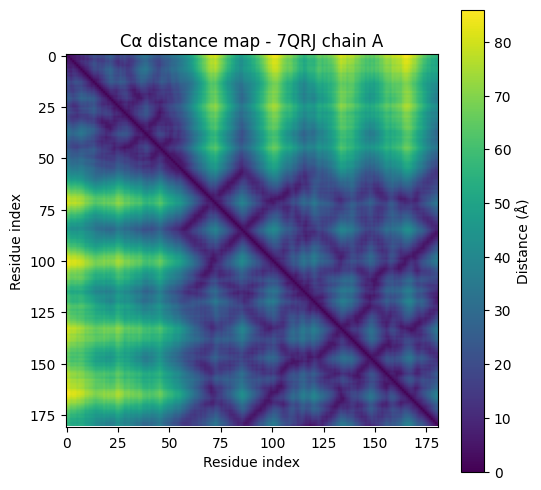

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

D = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1))

plt.figure(figsize=(6,6))
plt.imshow(D)
plt.colorbar(label="Distance (Å)")
plt.title("Cα distance map - 7QRJ chain A")
plt.xlabel("Residue index")
plt.ylabel("Residue index")
plt.show()

---

# Construir el Dataset

In [ ]:
import sys, os

root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

from data.collate_proteins import * 
from data.dataloaders import *

In [47]:
dataset = FoldbenchProteinDataset(
    json_path="/content/af_subset/jsons/fb_protein.json",
    msa_root="/content/af_subset/foldbench_msas",
    cif_root="/content/af_subset/reference_structures",
    max_msa_seqs=128,
    min_identity=0.85,
    verbose=True,)

print("N ejemplos finales:", len(dataset))
print("Primeros descartados:", dataset.dropped[:10])

sample = dataset[0]
for k, v in sample.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v), v)

Dataset valid examples: 39
Dropped examples: 200
  query_name msa_chain_id matched_chain_id  match_identity
0       7QRJ            A                A        1.000000
1       7QRR            A                F        1.000000
2       7QUV            A                B        1.000000
3       7SPQ            A                A        1.000000
4       7TH0            A                A        0.953488
N ejemplos finales: 39
Primeros descartados: [('7QWE', 'no_msa'), ('7XPT', 'no_msa'), ('7XVQ', 'no_msa'), ('7Y37', 'no_chain_match'), ('7YLS', 'no_msa'), ('7YUL', 'no_msa'), ('7ZOP', 'no_msa'), ('8A51', 'no_msa'), ('8AMY', 'no_msa'), ('8AN5', 'no_msa')]
id <class 'str'> 7QRJ
msa_chain_id <class 'str'> A
matched_chain_id <class 'str'> A
match_identity torch.Size([]) torch.float32
sequence_str <class 'str'> MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSIT
seq_to

In [ ]:


from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_proteins)

batch = next(iter(loader))

for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v))

id <class 'list'>
msa_chain_id <class 'list'>
matched_chain_id <class 'list'>
match_identity torch.Size([2]) torch.float32
sequence_str <class 'list'>
seq_tokens torch.Size([2, 250]) torch.int64
seq_mask torch.Size([2, 250]) torch.float32
msa_tokens torch.Size([2, 128, 250]) torch.int64
msa_mask torch.Size([2, 128, 250]) torch.float32
coords_n torch.Size([2, 250, 3]) torch.float32
coords_ca torch.Size([2, 250, 3]) torch.float32
coords_c torch.Size([2, 250, 3]) torch.float32
dist_map torch.Size([2, 250, 250]) torch.float32
valid_res_mask torch.Size([2, 250]) torch.float32
valid_backbone_mask torch.Size([2, 250]) torch.float32
pair_mask torch.Size([2, 250, 250]) torch.float32
backbone_pair_mask torch.Size([2, 250, 250]) torch.float32


In [18]:
dataset.df["match_identity"].describe()

,match_identity
count,39.000000
mean,0.991809
std,0.023664
min,0.875000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [19]:
dataset.df[["query_name", "msa_chain_id", "matched_chain_id", "match_identity"]].head(20)

,query_name,msa_chain_id,matched_chain_id,match_identity
0,7QRJ,A,A,1.000000
1,7QRR,A,F,1.000000
2,7QUV,A,B,1.000000
3,7SPQ,A,A,1.000000
4,7TH0,A,A,0.953488
5,7TXY,A,A,1.000000
6,7UQ2,A,A,1.000000
7,7VUB,A,A,1.000000
8,7WR3,A,A,0.989924
9,7X36,A,A,1.000000


---